# Differential Methylation: single CpGs
1. `DSS::DMLtest(.., smoothing = FALSE, equal.disp = TRUE)`
2. `modkit dmr pair`

**DML outputs**

    chr: Chromosome number.

    pos: Genomic coordinates.

    mu1, mu2: Mean methylations of two groups.

    diff: Difference of mean methylations of two groups. diff=mu1-mu2.

    diff.se: Standard error of the methylation difference.

    stat: Wald statistics.

    pval: P-values. This is obtained from normal distribution.

    fdr: False discovery rate.

##### Modules

In [1]:
import os
import pandas as pd
import numpy as np
from pybedtools import BedTool

import upsetplot
from matplotlib_venn import venn2, venn2_circles
import seaborn as sb
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib import font_manager
from matplotlib.ticker import MaxNLocator
from matplotlib.colors import LogNorm
import matplotlib.colors as mcolors

from statsmodels.stats.multitest import multipletests
import scipy.stats as stats

##### Functions

In [2]:
def AddRegion(sets, region):
    if region:  # non-empty
        memberships.append(tuple(sets))
        counts.append(len(region))

##### Fonts & Colors

In [3]:
# font style
locations = ['/home/eger/software/fonts']
font_files = font_manager.findSystemFonts(fontpaths = locations)
for file in font_files:
    font_manager.fontManager.addfont(file)
plt.rcParams['font.family'] = 'Aptos'

# fig size
plt.rcParams['figure.figsize'] = (15, 10)

# font size
title_size = 20
label_size = 18
tick_size = 16

colors = plt.cm.Set2.colors

##### Inputs

In [4]:
dmr_cols = [
    'chrom',
    'start',
    'end',
    'name',
    'score',
    'strand',
    'a_counts',
    'a_total',
    'b_counts',
    'b_total',
    'a_mod_percentages',
    'b_mod_percentages',
    'a_pct_modified',
    'b_pct_modified',
    'map_pvalue',
    'effect_size',
    'cohen_h', 
    'cohen_h_low',
    'cohen_h_high'
]

In [5]:
REF_DIR = '/scratch/eger/projects/MethSmoothEval/tissues/ref_data'

DIR0 = '/scratch/eger/projects/MethSmoothEval/tissues/modkit/pileup'
DIR1 = '/scratch/eger/projects/MethSmoothEval/tissues/modkit/dmr'
DIR2 = '/scratch/eger/projects/MethSmoothEval/tissues/DSS'
OUTDIR = '/scratch/eger/projects/MethSmoothEval/tissues/DM_analysis'

In [6]:
# cell type indication region of the major cell types in brain and blood
ref_bed1 = os.path.join(REF_DIR, 'sniffcell_find_brain_blood.bed')
regions1 = BedTool(ref_bed1)

In [7]:
p_thres = 0.05

## Bulk_FC_Control_02 v. hg002_blood

Load the DMR results

In [19]:
sample1 = 'Bulk_FC_Control_02'
sample2 = 'hg002_blood'
fname1 = os.path.join(DIR1, sample1+'_v_'+sample2+'.dmr.bed.gz')
fname2 = os.path.join(DIR2, sample1+'_v_'+sample2+'_DMLtestwSmoothing.tsv.gz')

df1 = pd.read_csv(fname1, sep='\t', header=None, names=dmr_cols)
df2 = pd.read_csv(fname2, sep='\t')

### All CpGs

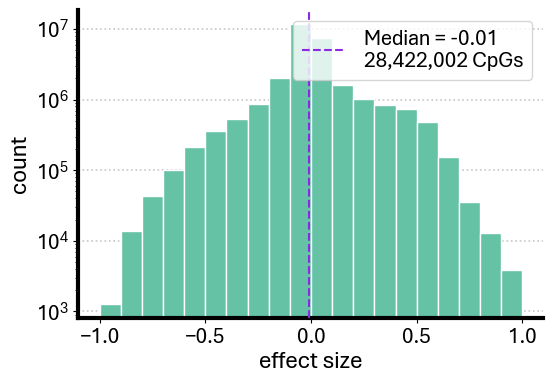

In [20]:
vals = df1['effect_size']
x_name = 'effect size'

fig, ax = plt.subplots(figsize=(6, 4))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
ax.grid(axis='y', linestyle=':', alpha=0.7, zorder=0, linewidth=1.2)

# Labeling the axes
ax.tick_params(axis='both', labelsize=tick_size)

ax.hist(vals, 
        bins=20, edgecolor='white', color=colors[0], zorder=2)
ax.set_yscale('log')
ax.set_xlabel(x_name, fontsize=label_size)
ax.set_ylabel('count', fontsize=label_size)

median = vals.median()
ax.axvline(median, color='blueviolet', linestyle='--', 
       linewidth=1.5, zorder=4, 
       label=f'Median = {median:.2f}\n{len(vals):,} CpGs')
ax.legend(fontsize=tick_size)
    
plt.show()

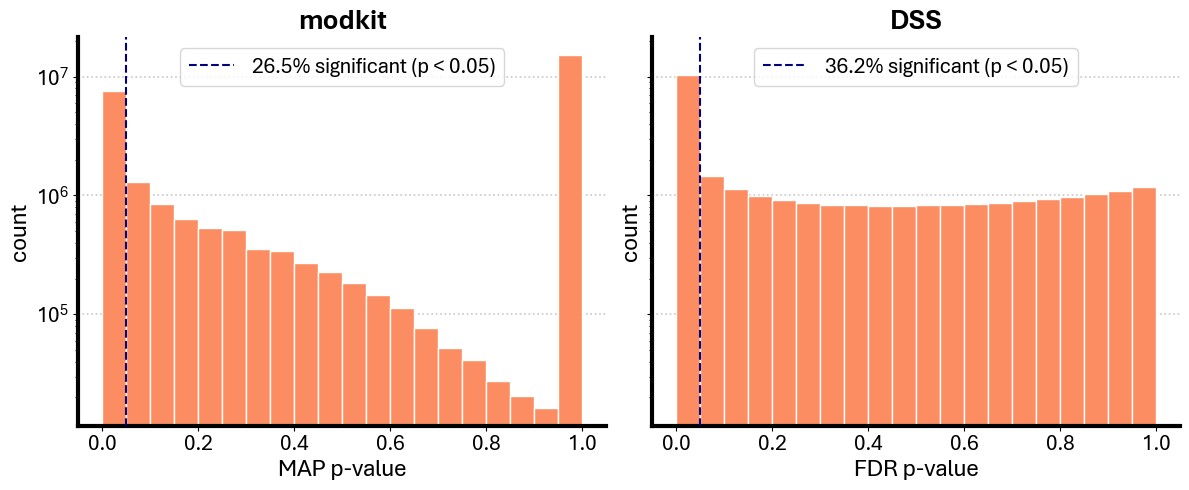

In [21]:
test_dict = {'modkit': df1['map_pvalue'],
            'DSS': df2['fdr']}

# Plotting setup
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
axes = axes.ravel()

for i,test in enumerate(test_dict.keys()):
    ax = axes[i]
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(3)
    ax.spines['left'].set_linewidth(3)
    ax.grid(axis='y', linestyle=':', alpha=0.7, zorder=0, linewidth=1.2)

    # Labeling the axes
    ax.tick_params(axis='both', labelsize=tick_size)

    ax.hist(test_dict[test], bins=20, edgecolor='white', color=colors[1], zorder=2)
    ax.set_yscale('log')

    if test == 'modkit':
        ax.set_xlabel('MAP p-value', fontsize=label_size)
    else:
        ax.set_xlabel('FDR p-value', fontsize=label_size)
    ax.set_ylabel('count', fontsize=label_size)

    pct_sig = (test_dict[test] < p_thres).sum() / len(test_dict[test]) * 100
    ax.axvline(p_thres, color='navy', linestyle='--', 
           linewidth=1.5, zorder=4, 
           label=f'{pct_sig:.1f}% significant (p < {p_thres})')
    ax.legend(fontsize=tick_size, loc='upper center')
    ax.set_title(test, fontsize=title_size, fontweight='bold')
    
plt.tight_layout()
plt.show()

### Significant CpGs

In [23]:
df1 = df1[df1['map_pvalue'] < p_thres]
df2 = df2[df2['fdr'] < p_thres]

In [24]:
# add name column
df1.index = df1['chrom']+':'+df1['end'].astype(str)
df2.index = df2['chr']+':'+df2['pos'].astype(str)

Get numbers of significant DMPs.

In [25]:
print('modkit MAP p-val < 0.05 DMPs:', f'{df1.shape[0]:,}')
print('DMLwSmooth FDR p-val < 0.05 DMPs:', f'{df2.shape[0]:,}')

modkit MAP p-val < 0.05 DMPs: 7,520,756
DMLwSmooth FDR p-val < 0.05 DMPs: 10,293,384


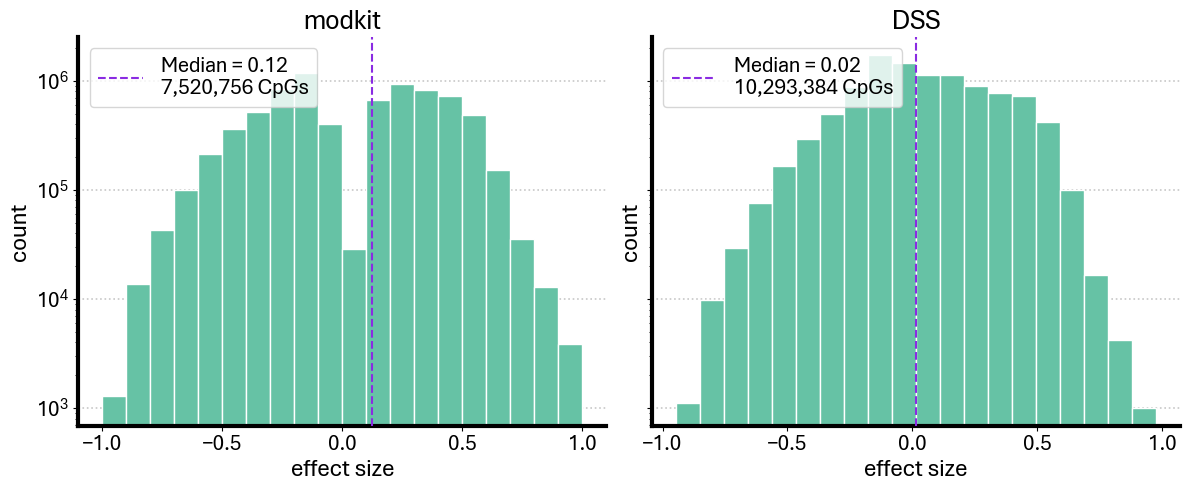

In [26]:
test_dict = {'modkit': df1,
            'DSS': df2}

# Plotting setup
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
axes = axes.ravel()

for i,test in enumerate(test_dict.keys()):
    ax = axes[i]
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(3)
    ax.spines['left'].set_linewidth(3)
    ax.grid(axis='y', linestyle=':', alpha=0.7, zorder=0, linewidth=1.2)

    # Labeling the axes
    ax.tick_params(axis='both', labelsize=tick_size)

    if test == 'modkit':
        col = 'effect_size'
    else:
        col = 'diff'
    vals = np.array(test_dict[test][col])
    
    ax.hist(vals, bins=20, edgecolor='white', color=colors[0], zorder=2)
    ax.set_yscale('log')
    ax.set_xlabel('effect size', fontsize=label_size)
    ax.set_ylabel('count', fontsize=label_size)

    median = np.median(vals)
    ax.axvline(median, color='blueviolet', linestyle='--', 
       linewidth=1.5, zorder=4, 
       label=f'Median = {median:.2f}\n{len(vals):,} CpGs')
    
    ax.legend(fontsize=tick_size)
    ax.set_title(test, fontsize=title_size)
    
plt.tight_layout()
plt.show()

### Overlapping & Unique CpGs

In [27]:
A_set = set(df1.index)
B_set = set(df2.index)

In [29]:
A_only = A_set - B_set
B_only = B_set - A_set
AB    = A_set & B_set

memberships = []
counts = []

AddRegion(['modkit'],      A_only)
AddRegion(['DSS'],      B_only)
AddRegion(['modkit','DSS'],  AB)

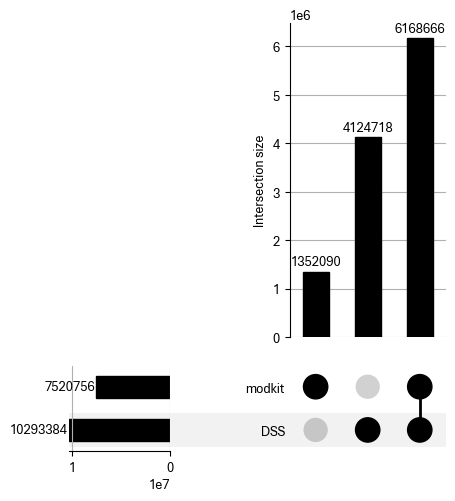

In [48]:
data = upsetplot.from_memberships(memberships, data=counts)
plot_result = upsetplot.plot(data, show_counts=True, sort_by='-cardinality', element_size=50)
plt.show()

Convert to BedTools

In [36]:
A = BedTool.from_dataframe(df1[['chrom', 'start', 'end']])

df2['start'] = df2['pos'] - 1
B = BedTool.from_dataframe(df2[['chr', 'start', 'pos']])

AB = BedTool.from_dataframe(df1.loc[list(AB)][['chrom', 'start', 'end']])

In [41]:
# modkit and DSS only DMPs
A_only = A.intersect(B, v=True)    # -v = report B entries with no overlap in A
B_only = B.intersect(A, v=True)   

In [ ]:
# Make ±500 bp windows around shared DMPs (AB)
#    'genome' must be a chrom sizes spec: a file, "hg38", dict, etc.
AB_500 = AB.slop(b=500, genome='hg38')  # or genome='hg19', or a path to a chromsizes file

In [42]:
# DMPs that are within 500 bp of any shared DMP
A_near = A_only.intersect(AB_500, u=True) 
B_near = B_only.intersect(AB_500, u=True)   # -u = keep each B_only feature once if it overlaps any window

# DMPs that are >500 bp from all shared DMPs
A_far = A_only.intersect(AB_500, v=True)
B_far = B_only.intersect(AB_500, v=True)    # -v = keep B_only features with NO overlap with any window

In [ ]:
# Counts
n_A_only = A_only.count()
n_A_near = A_near.count()
n_A_far  = A_far.count()

n_B_only = B_only.count()
n_B_near = B_near.count()
n_B_far  = B_far.count()

In [58]:
print(f'{n_A_near:,}/{n_A_only:,} = {n_A_near / n_A_only*100:.1f}% modkit-only DMPs < 500 bp of shared DMPs')
print(f'{n_B_near:,}/{n_B_only:,} = {n_B_near / n_B_only*100:.1f}% DSS-only DMPs < 500 bp of shared DMPs')

468,659/1,352,090 = 34.7% modkit-only DMPs < 500 bp of shared DMPs
3,785,835/4,124,718 = 91.8% DSS-only DMPs < 500 bp of shared DMPs


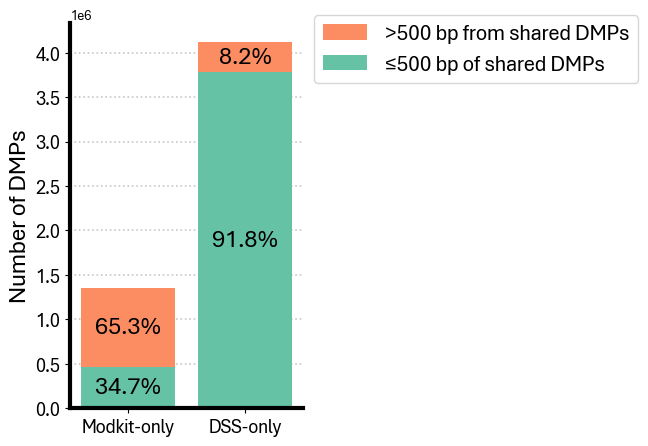

In [60]:
labels = ["Modkit-only", "DSS-only"]
near_counts = np.array([n_A_near, n_B_near])
far_counts  = np.array([n_A_far,  n_B_far])

# Compute percentages for labeling
near_pct = near_counts / (near_counts + far_counts) * 100
far_pct  = 100 - near_pct

fig, ax = plt.subplots(figsize=(3, 5))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
ax.grid(axis='y', linestyle=':', alpha=0.7, zorder=0, linewidth=1.2)

# Stacked bars
bars2 = ax.bar(labels, far_counts, bottom=near_counts, label=">500 bp from shared DMPs", zorder=2, color=colors[1])
bars1 = ax.bar(labels, near_counts, label="≤500 bp of shared DMPs", zorder=2, color=colors[0])


# Add percentage labels
for i in range(len(labels)):
    ax.text(i, near_counts[i] / 2,
            f"{near_pct[i]:.1f}%",
            ha="center", va="center", fontsize=label_size)
    
    ax.text(i, near_counts[i] + far_counts[i] / 2,
            f"{far_pct[i]:.1f}%",
            ha="center", va="center", fontsize=label_size)
ax.tick_params(axis='both', labelsize=14)
ax.set_ylabel("Number of DMPs", fontsize=label_size)
ax.legend(fontsize=tick_size, bbox_to_anchor=(1, 1.05))

plt.show()

### Intersection with cell type indicator regions

In [78]:
A_only.intersect(regions1).count()

10594

In [69]:
# DMPs within the regions
A_only_reg1 = A_only.intersect(regions1, u=True) 
B_only_reg1 = B_only.intersect(regions1, u=True)   # -u = keep each B_only feature once if it overlaps any window
AB_reg1 = AB.intersect(regions1, u=True) 

In [70]:
n_A_only_reg1 = A_only_reg1.count()
n_B_only_reg1 = B_only_reg1.count()
n_AB_reg1 = AB_reg1.count()

In [76]:
print(f'{n_A_only_reg1:,}/{n_A_only:,} = {n_A_only_reg1 / n_A_only*100:.1f}% modkit-only DMPs in regions')
print(f'{n_B_only_reg1:,}/{n_B_only:,} = {n_B_only_reg1 / n_B_only*100:.1f}% DSS-only DMPs in regions')
print(f'{n_AB_reg1:,}/{AB.count():,} = {n_AB_reg1 / AB.count()*100:.1f}% shared DMPs in regions')

10,594/1,352,090 = 0.8% modkit-only DMPs in regions
55,537/4,124,718 = 1.3% DSS-only DMPs in regions
326,727/6,168,666 = 5.3% shared DMPs in regions


In [61]:
df1_reg1 = pd.read_table(A_only.intersect(regions1).fn, names=['chr', 'start', 'end'])
df2_reg1 = pd.read_table(B_only.intersect(regions1).fn, names=['chr', 'start', 'end'])

In [62]:
df1_reg1.index = df1_reg1['chr']+':'+df1_reg1['end'].astype(str)
df2_reg1.index = df2_reg1['chr']+':'+df2_reg1['end'].astype(str)

In [63]:
A_reg1 = set(df1_reg1.index)
B_reg1 = set(df2_reg1.index)

## hg002_blood v. colo829bl

Load the DMR results

In [79]:
sample1 = 'hg002_blood'
sample2 = 'colo829bl'
fname1 = os.path.join(DIR1, sample1+'_v_'+sample2+'.dmr.bed.gz')
fname2 = os.path.join(DIR2, sample1+'_v_'+sample2+'_DMLtestwSmoothing.tsv.gz')

df1 = pd.read_csv(fname1, sep='\t', header=None, names=dmr_cols)
df2 = pd.read_csv(fname2, sep='\t')

### All CpGs

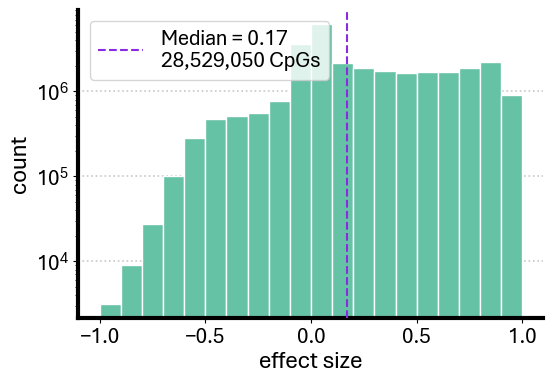

In [80]:
vals = df1['effect_size']
x_name = 'effect size'

fig, ax = plt.subplots(figsize=(6, 4))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_linewidth(3)
ax.spines['left'].set_linewidth(3)
ax.grid(axis='y', linestyle=':', alpha=0.7, zorder=0, linewidth=1.2)

# Labeling the axes
ax.tick_params(axis='both', labelsize=tick_size)

ax.hist(vals, 
        bins=20, edgecolor='white', color=colors[0], zorder=2)
ax.set_yscale('log')
ax.set_xlabel(x_name, fontsize=label_size)
ax.set_ylabel('count', fontsize=label_size)

median = vals.median()
ax.axvline(median, color='blueviolet', linestyle='--', 
       linewidth=1.5, zorder=4, 
       label=f'Median = {median:.2f}\n{len(vals):,} CpGs')
ax.legend(fontsize=tick_size)
    
plt.show()

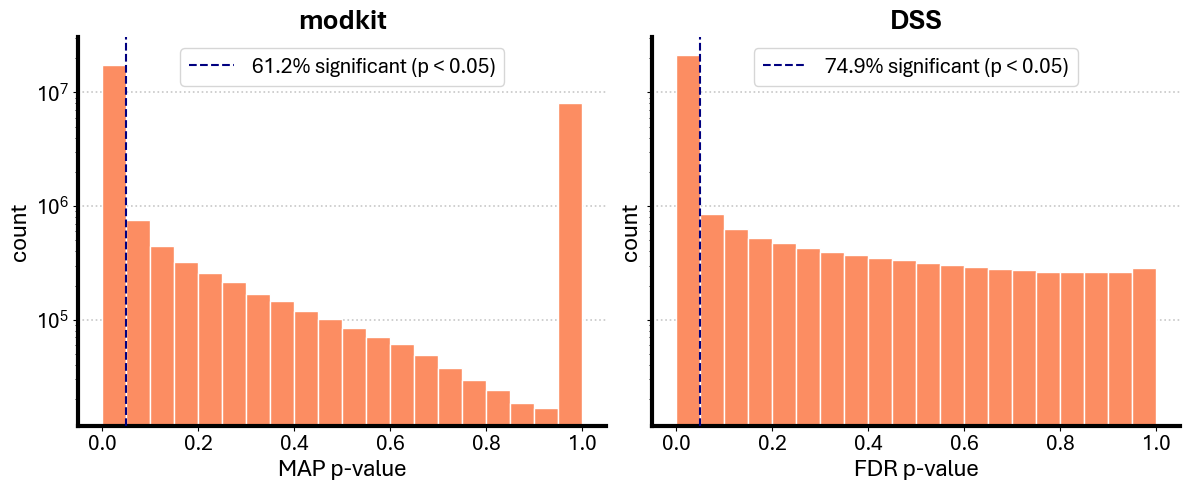

In [81]:
test_dict = {'modkit': df1['map_pvalue'],
            'DSS': df2['fdr']}

# Plotting setup
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
axes = axes.ravel()

for i,test in enumerate(test_dict.keys()):
    ax = axes[i]
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(3)
    ax.spines['left'].set_linewidth(3)
    ax.grid(axis='y', linestyle=':', alpha=0.7, zorder=0, linewidth=1.2)

    # Labeling the axes
    ax.tick_params(axis='both', labelsize=tick_size)

    ax.hist(test_dict[test], bins=20, edgecolor='white', color=colors[1], zorder=2)
    ax.set_yscale('log')

    if test == 'modkit':
        ax.set_xlabel('MAP p-value', fontsize=label_size)
    else:
        ax.set_xlabel('FDR p-value', fontsize=label_size)
    ax.set_ylabel('count', fontsize=label_size)

    pct_sig = (test_dict[test] < p_thres).sum() / len(test_dict[test]) * 100
    ax.axvline(p_thres, color='navy', linestyle='--', 
           linewidth=1.5, zorder=4, 
           label=f'{pct_sig:.1f}% significant (p < {p_thres})')
    ax.legend(fontsize=tick_size, loc='upper center')
    ax.set_title(test, fontsize=title_size, fontweight='bold')
    
plt.tight_layout()
plt.show()

### Significant CpGs

In [82]:
df1 = df1[df1['map_pvalue'] < p_thres]
df2 = df2[df2['fdr'] < p_thres]

In [83]:
# add name column
df1.index = df1['chrom']+':'+df1['end'].astype(str)
df2.index = df2['chr']+':'+df2['pos'].astype(str)

Get numbers of significant DMPs.

In [84]:
print('modkit MAP p-val < 0.05 DMPs:', f'{df1.shape[0]:,}')
print('DMLwSmooth FDR p-val < 0.05 DMPs:', f'{df2.shape[0]:,}')

modkit MAP p-val < 0.05 DMPs: 17,467,303
DMLwSmooth FDR p-val < 0.05 DMPs: 21,362,713


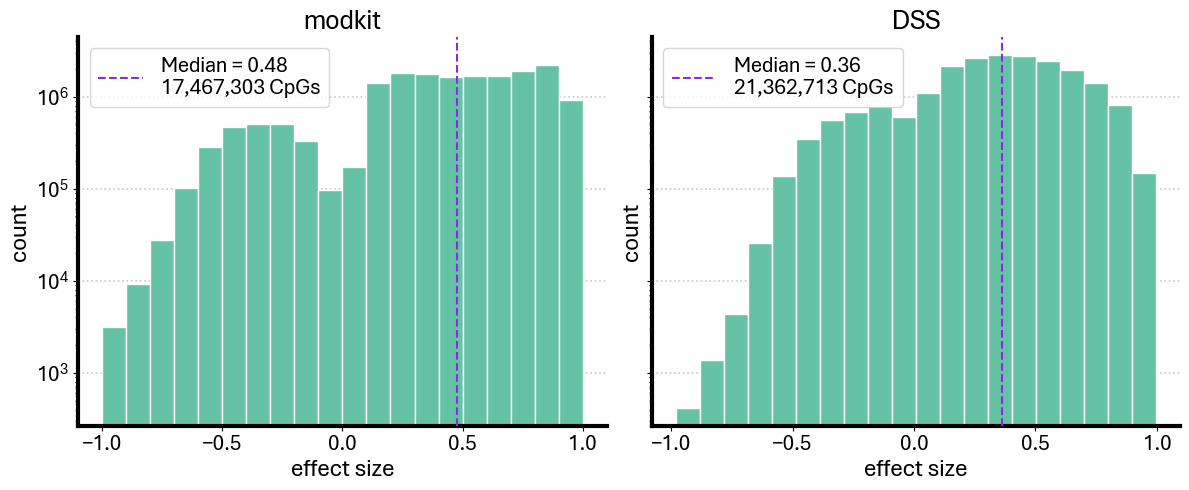

In [85]:
test_dict = {'modkit': df1,
            'DSS': df2}

# Plotting setup
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
axes = axes.ravel()

for i,test in enumerate(test_dict.keys()):
    ax = axes[i]
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(3)
    ax.spines['left'].set_linewidth(3)
    ax.grid(axis='y', linestyle=':', alpha=0.7, zorder=0, linewidth=1.2)

    # Labeling the axes
    ax.tick_params(axis='both', labelsize=tick_size)

    if test == 'modkit':
        col = 'effect_size'
    else:
        col = 'diff'
    vals = np.array(test_dict[test][col])
    
    ax.hist(vals, bins=20, edgecolor='white', color=colors[0], zorder=2)
    ax.set_yscale('log')
    ax.set_xlabel('effect size', fontsize=label_size)
    ax.set_ylabel('count', fontsize=label_size)

    median = np.median(vals)
    ax.axvline(median, color='blueviolet', linestyle='--', 
       linewidth=1.5, zorder=4, 
       label=f'Median = {median:.2f}\n{len(vals):,} CpGs')
    
    ax.legend(fontsize=tick_size)
    ax.set_title(test, fontsize=title_size)
    
plt.tight_layout()
plt.show()

### Overlapping & Unique CpGs

In [27]:
A_set = set(df1.index)
B_set = set(df2.index)

In [29]:
A_only = A_set - B_set
B_only = B_set - A_set
AB    = A_set & B_set

memberships = []
counts = []

AddRegion(['modkit'],      A_only)
AddRegion(['DSS'],      B_only)
AddRegion(['modkit','DSS'],  AB)

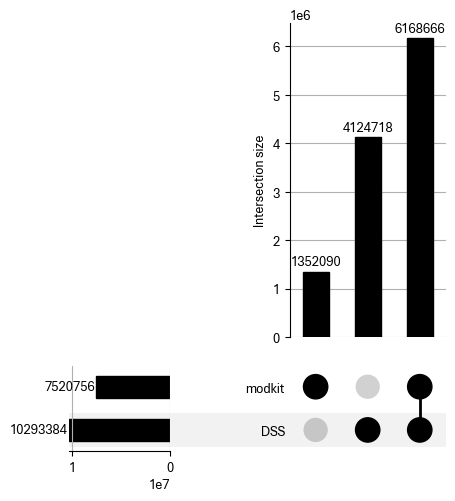

In [48]:
data = upsetplot.from_memberships(memberships, data=counts)
plot_result = upsetplot.plot(data, show_counts=True, sort_by='-cardinality', element_size=50)
plt.show()